# 시계열 데이터
- 1975년부터 2025년까지 연도별 통계 자료
- 방한 외래관광객, 국민 해외관광객

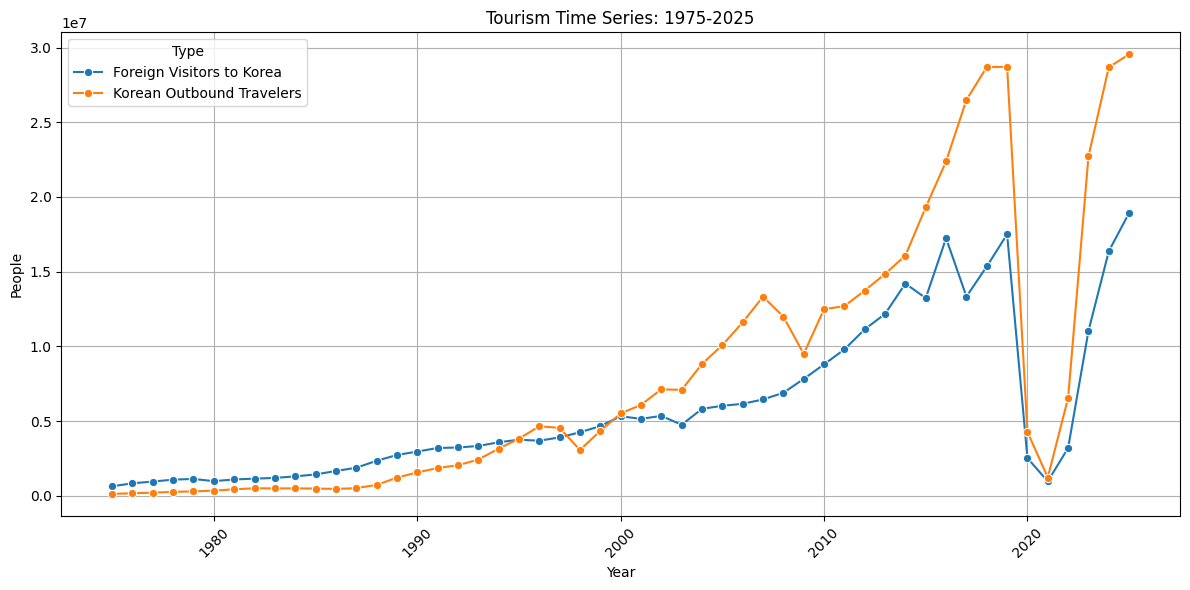

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

inbound = pd.read_excel('/content/연도별통계(1975-2025).xlsx', sheet_name='방한 외래관광객', header=4)
outbound = pd.read_excel('/content/연도별통계(1975-2025).xlsx', sheet_name='국민 해외관광객', header=4)

# 연도와 합계 열만 선택
inbound = inbound[['연  도', '계']]
outbound = outbound[['연 도', '계']]

# 열 이름 정리
inbound.columns = ['Year', 'Value']
outbound.columns = ['Year', 'Value']

# 숫자가 아닌 행 제거
inbound['Year'] = pd.to_numeric(inbound['Year'], errors='coerce')
inbound['Value'] = pd.to_numeric(inbound['Value'], errors='coerce')
outbound['Year'] = pd.to_numeric(outbound['Year'], errors='coerce')
outbound['Value'] = pd.to_numeric(outbound['Value'], errors='coerce')

inbound = inbound.dropna()
outbound = outbound.dropna()

# 구분 열 추가
inbound['Type'] = 'Foreign Visitors to Korea'
outbound['Type'] = 'Korean Outbound Travelers'

# 두 데이터 합치기
df = pd.concat([inbound, outbound])

# 시계열 선 그래프
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year', y='Value', hue='Type', marker='o')

plt.xlabel('Year')
plt.ylabel('People')
plt.title('Tourism Time Series: 1975-2025')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()